In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import pandas as pd
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np

In [ ]:
# MAIN CODE
# actual values
#A=1= Positive Class , B=0=Negative Class
actual = [1,0,0,1,0,1,1,1,0,1,0]
# predicted values
predicted = [1,0,0,1,0,0,0,1,0,0,1]

In [ ]:
# Assignment (2)
# actual values
#A=1= Positive Class , B=0=Negative Class
actual =  [1,0,0,1,0,1,1,1,0,1,0,1,1,1,1,0,0,1]
# predicted values
predicted = [1,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0]

In [ ]:
# Assignment (3)
iris = datasets.load_iris()
df = pd.DataFrame(iris.data)
label = pd.DataFrame(iris.target)
y_bin = label_binarize(label, classes=[0, 1, 2])
X_train, X_test, y_train, y_test = train_test_split(df, y_bin, test_size=0.3, shuffle=True, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.3, shuffle=True, random_state=42)
model = OneVsRestClassifier(DecisionTreeClassifier(random_state=42))
model.fit(X_train, y_train)
predicted_prob = model.predict_proba(X_test)
predicted = model.predict(X_test)
y_test_flat = np.argmax(y_test, axis=1)
predicted_flat = np.argmax(predicted, axis=1)

In [ ]:
# Accuracy
print(f'Accuracy: {accuracy_score(y_test_flat, predicted_flat):.2f}')

# Confusion Matrix
print('\nConfusion Matrix:')
print(confusion_matrix(y_test_flat, predicted_flat))

# Classification Report
print('\nClassification Report:')
print(classification_report(y_test_flat, predicted_flat, target_names=iris.target_names))

Accuracy: 1.00

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [ ]:
# confusion matrix
matrix = confusion_matrix(actual,predicted, labels=[1,0])
print('Confusion matrix : \n',matrix)
acc=accuracy_score(actual,predicted)
print('Accuracy = ',acc)
matrix = classification_report(actual,predicted,labels=[1,0])
print('Classification Report \n')
print(matrix)

Confusion matrix : 
 [[3 3]
 [1 4]]
Accuracy =  0.6363636363636364
Classification Report 

              precision    recall  f1-score   support

           1       0.75      0.50      0.60         6
           0       0.57      0.80      0.67         5

    accuracy                           0.64        11
   macro avg       0.66      0.65      0.63        11
weighted avg       0.67      0.64      0.63        11



In [ ]:
fpr, tpr , _= metrics.roc_curve(actual, predicted) #create ROC curve
print('fpr = ',fpr)
print('tpr = ',tpr)

fpr =  [0.         0.28571429 1.        ]
tpr =  [0.         0.27272727 1.        ]


In [ ]:
y_scores = model.predict_proba(X_test)
pos_label_index = 2

y_test_bin = label_binarize(actual, classes=[0, 1, 2])
y_test_curr_class = y_test_bin[:, pos_label_index]
y_score_curr_class = y_scores[:, pos_label_index]

fpr, tpr, _ = metrics.roc_curve(y_test_curr_class, y_score_curr_class)
roc_auc = metrics.auc(fpr, tpr)

NameError: name 'model' is not defined

In [ ]:
plt.plot(fpr,tpr)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

NameError: name 'fpr' is not defined

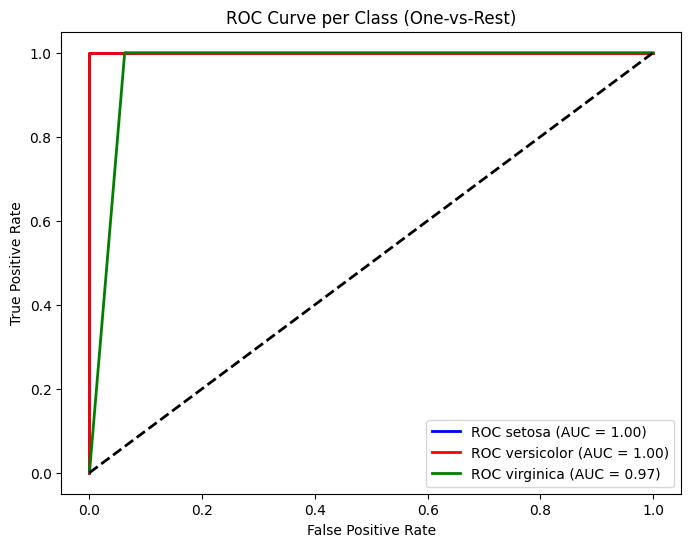

In [ ]:
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = 3

plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green']

for i in range(n_classes):
    # Calculate ROC for the specific class i vs the rest
    fpr[i], tpr[i], _ = metrics.roc_curve(y_test[:, i], predicted_prob[:, i])
    roc_auc[i] = metrics.auc(fpr[i], tpr[i])

    # Plot the line
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'ROC {iris.target_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve per Class (One-vs-Rest)')
plt.legend(loc="lower right")
plt.show()